# Advanced ML Project — Horse vs. Zebra Classification

This notebook trains and compares three model families — a from-scratch
CNN, a fine-tuned CNN (ResNet18 / EfficientNet-B0), and a fine-tuned
Vision Transformer (ViT / DeiT) — on a binary "horse vs. zebra" image
classification task. All models are evaluated on a clean held-out test
set and on a separate, harder set of AI-generated "tricky" images, to
measure robustness beyond the training distribution.


## 1. Setup — Mount Drive & Extract Data

Mounts Google Drive and extracts the raw image archive (`horse/`,
`zebra/` folders) into the local Colab runtime.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Configuration

All file paths used throughout this notebook are derived from the
variables below. If you run this notebook outside Colab (or with your
own Drive layout), you only need to change `BASE_DIR` / `DRIVE_DIR` here
— nothing else in the notebook needs to be edited.


In [ ]:
import os

BASE_DIR = "/content"                               # local Colab runtime working dir
DRIVE_DIR = "/content/drive/MyDrive"                 # persistent storage (Google Drive)

DATA_DIR = f"{BASE_DIR}/data"                        # raw extracted images (horse/, zebra/)
DATASET_DIR = f"{BASE_DIR}/dataset"                  # train/val/test split (original resolution)
DATASET_RESIZED_DIR = f"{BASE_DIR}/dataset_resized"  # train/val/test split (256x256, cached)
AI_TEST_DIR = f"{BASE_DIR}/ai_test"                  # AI-generated "tricky" test images

DRIVE_DATASET_RESIZED = f"{DRIVE_DIR}/dataset_resized"
OUTPUT_DIR = DRIVE_DIR                               # models / plots / history are saved here

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
!unzip -q {DRIVE_DIR}/data.zip -d {BASE_DIR}/


## 2. Data Quality Check — Duplicate Removal

Exact duplicate files are detected via MD5 hashing and removed **before**
the train/val/test split. Skipping this step could let the same image
end up in both the training and test sets, causing data leakage and an
inflated evaluation score.

**Result:** raw dataset of 1,712 images → 1,705 after removing 7
duplicates (856 horse / 849 zebra).


In [ ]:
import hashlib
import os

def get_file_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for cls in ['horse', 'zebra']:
    src_dir = f'{DATA_DIR}/{cls}'
    for fname in os.listdir(src_dir):
        path = os.path.join(src_dir, fname)
        h = get_file_hash(path)
        if h in hashes:
            duplicates.append((hashes[h], path))
        else:
            hashes[h] = path

print(f"Total {len(duplicates)} duplicates found:")
for original, dup in duplicates:
    print(f"{original}  <->  {dup}")

for original, dup in duplicates:
    os.remove(dup)
    print(f"Deleted: {dup}")


Total 7 duplicates found:
/content/data/zebra/david-vives-jDwx-obR3IE-unsplash.jpg  <->  /content/data/zebra/sorkııı.jpg
/content/data/zebra/dan-cutler-3CCt4DcycWA-unsplash.jpg  <->  /content/data/zebra/soru2.jpg
/content/data/zebra/hbieser-zebra-6018148_1920 (1).jpg  <->  /content/data/zebra/hbieser-zebra-6018148_1920.jpg
/content/data/zebra/bunu_dasor.jpg  <->  /content/data/zebra/ed-wingate-r2WURq1RdwA-unsplash.jpg
/content/data/zebra/Kruger_National_Park_(ZA),_Zebra_--_2024_--_1028.jpg  <->  /content/data/zebra/Kruger_National_Park_(ZA),_Zebra_--_2024_--_1028 (1).jpg
/content/data/zebra/janosch-diggelmann-VqcUjPStBCM-unsplash (1).jpg  <->  /content/data/zebra/janosch-diggelmann-VqcUjPStBCM-unsplash.jpg
/content/data/zebra/bunu_sor.jpg  <->  /content/data/zebra/kelly-arnold-3HKP9C0Y2nI-unsplash.jpg
Deleted: /content/data/zebra/sorkııı.jpg
Deleted: /content/data/zebra/soru2.jpg
Deleted: /content/data/zebra/hbieser-zebra-6018148_1920.jpg
Deleted: /content/data/zebra/ed-wingate-r2WURq1

In [ ]:
print("Folders:", os.listdir(DATA_DIR))
print("Horse count:", len(os.listdir(f'{DATA_DIR}/horse')))
print("Zebra count:", len(os.listdir(f'{DATA_DIR}/zebra')))


Folders: ['horse', 'zebra']
Horse count: 856
Zebra count: 849


## 3. Train / Val / Test Split

A fixed `random_state=42` split (70/15/15) is used so the split is
reproducible across runs.


In [ ]:
import shutil, os
from sklearn.model_selection import train_test_split

random_state = 42

shutil.rmtree(DATASET_DIR, ignore_errors=True)
shutil.rmtree(DATASET_RESIZED_DIR, ignore_errors=True)

for cls in ['horse', 'zebra']:
    files = sorted(os.listdir(f'{DATA_DIR}/{cls}'))

    train, temp = train_test_split(files, test_size=0.3, random_state=random_state)
    val, test = train_test_split(temp, test_size=0.5, random_state=random_state)

    for split_name, split_files in [('train', train), ('val', val), ('test', test)]:
        out_dir = f'{DATASET_DIR}/{split_name}/{cls}'
        os.makedirs(out_dir, exist_ok=True)
        for f in split_files:
            shutil.copy(f'{DATA_DIR}/{cls}/{f}', f'{out_dir}/{f}')

    print(f"{cls} -> train: {len(train)}, val: {len(val)}, test: {len(test)}")


horse -> train: 599, val: 128, test: 129
zebra -> train: 594, val: 127, test: 128


## 4. Resize (Performance Optimization)

Some of the original source images (mainly from Unsplash) are extremely
high-resolution (up to ~150 megapixels), which triggered PIL's
`DecompressionBombWarning` and slowed down every epoch's I/O. Images are
resized once to 256×256 and cached to disk so all subsequent training
runs load quickly.


In [ ]:
import os
from PIL import Image

def resize_dataset(src_root, dst_root, size=256):
    for split in ['train', 'val', 'test']:
        for cls in os.listdir(os.path.join(src_root, split)):
            src_dir = os.path.join(src_root, split, cls)
            dst_dir = os.path.join(dst_root, split, cls)
            os.makedirs(dst_dir, exist_ok=True)

            for fname in os.listdir(src_dir):
                src_path = os.path.join(src_dir, fname)
                dst_path = os.path.join(dst_dir, fname)

                with Image.open(src_path) as img:
                    img = img.convert("RGB")
                    img = img.resize((size, size))
                    img.save(dst_path, quality=90)

resize_dataset(DATASET_DIR, DATASET_RESIZED_DIR, size=256)

print("Test horse:", len(os.listdir(f'{DATASET_RESIZED_DIR}/test/horse')))
print("Test zebra:", len(os.listdir(f'{DATASET_RESIZED_DIR}/test/zebra')))


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (150000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Test horse: 129
Test zebra: 128


## 5. Save Resized Dataset to Drive

Run once — this way the extraction/split/resize pipeline does not need
to be repeated even if the Colab runtime is reset.


In [ ]:
import shutil

shutil.rmtree(DRIVE_DATASET_RESIZED, ignore_errors=True)
shutil.copytree(DATASET_RESIZED_DIR, DRIVE_DATASET_RESIZED)

print("Saved cleanly to Drive!")


Saved cleanly to Drive!


## Resume Here in a New Session

If the runtime resets (or you reopen the notebook on a different day),
skip steps 1–5 and just run this cell — it copies the already-prepared
dataset from Drive into the local runtime.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.rmtree(DATASET_RESIZED_DIR, ignore_errors=True)
shutil.copytree(DRIVE_DATASET_RESIZED, DATASET_RESIZED_DIR)
print("Data loaded!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded!


## 6. Data Leakage Check

Confirms there is no filename overlap between the train/val/test splits.

**Result:** 0 overlapping files across all three sets.


In [ ]:
import os
train_files = set(os.listdir(f'{DATASET_RESIZED_DIR}/train/horse')) | set(os.listdir(f'{DATASET_RESIZED_DIR}/train/zebra'))
val_files = set(os.listdir(f'{DATASET_RESIZED_DIR}/val/horse')) | set(os.listdir(f'{DATASET_RESIZED_DIR}/val/zebra'))
test_files = set(os.listdir(f'{DATASET_RESIZED_DIR}/test/horse')) | set(os.listdir(f'{DATASET_RESIZED_DIR}/test/zebra'))

print("Train-Val overlap:", len(train_files & val_files))
print("Train-Test overlap:", len(train_files & test_files))
print("Val-Test overlap:", len(val_files & test_files))


Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


## 7. Fix Random Seed (Reproducibility)

Fixes seeds for `random`, `numpy`, and `torch` (including CUDA) and
disables cuDNN's non-deterministic algorithms, so results are
reproducible across runs.


In [ ]:
import torch
import numpy as np
import random

def set_seed(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(123)

## 8. Data Augmentation & DataLoaders (for SimpleCNN + ResNet18)

Standard ImageNet normalization statistics
(`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) are used,
shared by both the from-scratch model and ResNet18. Training-set
augmentations include random horizontal flip, rotation, color jitter,
and random affine transforms — intended to reduce reliance on
superficial, purely positional cues and improve generalization.


In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(f'{DATASET_RESIZED_DIR}/train', transform=train_transform)
val_dataset = datasets.ImageFolder(f'{DATASET_RESIZED_DIR}/val', transform=val_test_transform)
test_dataset = datasets.ImageFolder(f'{DATASET_RESIZED_DIR}/test', transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Classes: ['horse', 'zebra']
Train: 1193 | Val: 255 | Test: 257


## 9. Shared Training / Evaluation Functions

SimpleCNN, ResNet18, EfficientNet-B0, ViT, and DeiT all follow the same
training loop logic (train → validate → early-stop → checkpoint → log),
with the only difference being that the Transformer models' output is
accessed via `.logits`. Rather than duplicating this loop five times, a
single shared `train_model()` / `evaluate_model()` / `test_accuracy()`
set of functions is used for every model, parameterized by `is_vit`.
Early stopping (patience-based, monitored on validation loss) is used so
that each model trains only as long as it keeps improving.


In [ ]:
import torch
import json
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def train_model(model, train_loader, val_loader, criterion, optimizer,
                 num_epochs, device, is_vit=False, save_prefix=None,
                 early_stopping=True, patience=5):

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    def forward(model, images):
        return model(pixel_values=images).logits if is_vit else model(images)

    for epoch in range(num_epochs):
        # ---- TRAIN ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = forward(model, images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- VALIDATION ----
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = forward(model, images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # ---- EARLY STOPPING ----
        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_model_state = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping: val_loss did not improve for {patience} epochs, "
                          f"stopping at epoch {epoch+1}.")
                    break


    if early_stopping and best_model_state is not None:
        model.load_state_dict(best_model_state)

    if save_prefix:
        torch.save(model.state_dict(), f'/content/drive/MyDrive/model_{save_prefix}.pth')
        with open(f'/content/drive/MyDrive/history_{save_prefix}.json', 'w') as f:
            json.dump(history, f)

    return history


def plot_history(history, model_label, save_path):

    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_label} - Train vs Val Loss"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{model_label} - Train vs Val Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def evaluate_model(model, loader, class_names, is_vit=False, title="Model", save_path=None):

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(pixel_values=images).logits if is_vit else model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    if save_path:
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap="Blues")
        plt.title(f"Confusion Matrix - {title}")
        plt.savefig(save_path, dpi=150)
        plt.show()

    return all_preds, all_labels


def test_accuracy(model, loader, is_vit=False):

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits if is_vit else model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Model 1: SimpleCNN (From-Scratch)

A small convolutional network trained entirely from scratch (no
pretrained weights), used as the baseline to quantify how much value
transfer learning adds on this task.


### Model Architecture

3 convolutional blocks (16 → 32 → 64 channels) with BatchNorm, ReLU,
max-pooling, and dropout before the final fully-connected classification
head.


In [ ]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()


        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)


        # 224 -> pool1 -> 112 -> pool2 -> 56 -> pool3 -> 28
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

### Model Setup


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

model = SimpleCNN().to(device)  # modeli sıfırla
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # yeni optimizer bunu cıkar data setınden


using device: cuda


### Training (Shared Function)

Trained for up to 30 epochs with early stopping (patience=5, monitored
on validation loss).


Epoch 1/30 | Train Loss: 3.7653, Train Acc: 0.6999 | Val Loss: 0.3322, Val Acc: 0.8471
Epoch 2/30 | Train Loss: 0.4304, Train Acc: 0.8550 | Val Loss: 0.2700, Val Acc: 0.9059
Epoch 3/30 | Train Loss: 0.3483, Train Acc: 0.8692 | Val Loss: 0.2600, Val Acc: 0.9333
Epoch 4/30 | Train Loss: 0.3312, Train Acc: 0.8785 | Val Loss: 0.2273, Val Acc: 0.9216
Epoch 5/30 | Train Loss: 0.3306, Train Acc: 0.8776 | Val Loss: 0.2711, Val Acc: 0.8980
Epoch 6/30 | Train Loss: 0.3487, Train Acc: 0.8885 | Val Loss: 0.1995, Val Acc: 0.9451
Epoch 7/30 | Train Loss: 0.3303, Train Acc: 0.8684 | Val Loss: 0.2126, Val Acc: 0.9216
Epoch 8/30 | Train Loss: 0.2726, Train Acc: 0.8860 | Val Loss: 0.1901, Val Acc: 0.9412
Epoch 9/30 | Train Loss: 0.2586, Train Acc: 0.9078 | Val Loss: 0.2127, Val Acc: 0.9294
Epoch 10/30 | Train Loss: 0.2452, Train Acc: 0.9103 | Val Loss: 0.2045, Val Acc: 0.9294
Epoch 11/30 | Train Loss: 0.2501, Train Acc: 0.9170 | Val Loss: 0.2352, Val Acc: 0.9098
Epoch 12/30 | Train Loss: 0.2296, Train A

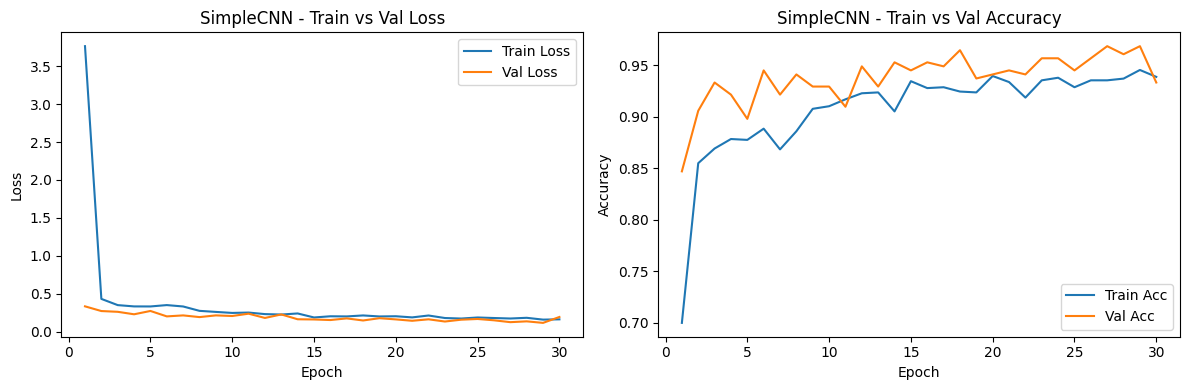

In [ ]:
history = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=30, device=device, is_vit=False, save_prefix="scratch_cnn",
    patience=5
)

plot_history(history, "SimpleCNN", f'{OUTPUT_DIR}/training_curves_scratch_cnn.png')


### Test Evaluation


              precision    recall  f1-score   support

       horse       0.95      0.96      0.95       129
       zebra       0.96      0.95      0.95       128

    accuracy                           0.95       257
   macro avg       0.95      0.95      0.95       257
weighted avg       0.95      0.95      0.95       257

Confusion Matrix:
[[124   5]
 [  7 121]]


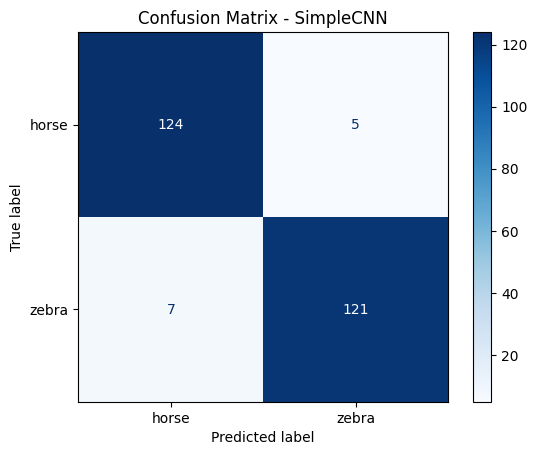

In [ ]:
_ = evaluate_model(
    model, test_loader, train_dataset.classes, is_vit=False,
    title="SimpleCNN", save_path=f'{OUTPUT_DIR}/confusion_matrix_scratch_cnn.png'
)


### Misclassified Examples

Visual inspection of the images the from-scratch model got wrong.


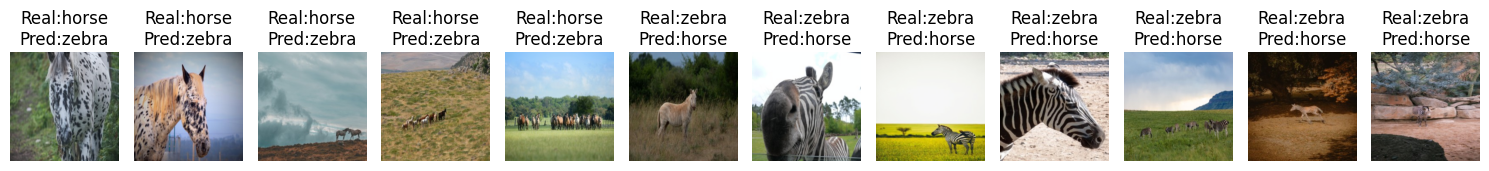

Total incorrect predictions: 12


In [ ]:
import matplotlib.pyplot as plt

model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu, labels_gpu = images.to(device), labels.to(device)
        outputs = model(images_gpu)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels_gpu[i]:
                wrong_images.append(images[i])
                wrong_true.append(labels[i].item())
                wrong_pred.append(predicted[i].item())

class_names = ['horse', 'zebra']
fig, axes = plt.subplots(1, max(len(wrong_images), 1), figsize=(15, 5))
if len(wrong_images) == 1:
    axes = [axes]
for i, img in enumerate(wrong_images):
    img = img.permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Real:{class_names[wrong_true[i]]}\nPred:{class_names[wrong_pred[i]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/wrong_predictions_scratch_cnn.png', dpi=150)
plt.show()

print(f"Total incorrect predictions: {len(wrong_images)}")


# Model 2: ResNet18 (Transfer Learning)

A ResNet18 pretrained on ImageNet, fully fine-tuned (all layers
trainable) with a low learning rate.


### Model Loading & Adaptation

All layers are fine-tuned (with a low learning rate).


In [ ]:
import torchvision.models as models

resnet_model = models.resnet18(weights='IMAGENET1K_V1')

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 2)
resnet_model = resnet_model.to(device)

for param in resnet_model.parameters():
    param.requires_grad = True  # tum katmanlar egitilebilir (fine-tuning)

print(resnet_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Linear(in_features=512, out_features=2, bias=True)


### Loss & Optimizer

Low learning rate (1e-4) since we are fine-tuning pretrained weights
rather than training from scratch.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.0001)  # dusuk lr, fine-tuning icin

### Training (Shared Function)


Epoch 1/20 | Train Loss: 0.1219, Train Acc: 0.9405 | Val Loss: 0.0052, Val Acc: 1.0000
Epoch 2/20 | Train Loss: 0.0282, Train Acc: 0.9899 | Val Loss: 0.0058, Val Acc: 1.0000
Epoch 3/20 | Train Loss: 0.0112, Train Acc: 0.9975 | Val Loss: 0.0056, Val Acc: 1.0000
Epoch 4/20 | Train Loss: 0.0095, Train Acc: 0.9983 | Val Loss: 0.0091, Val Acc: 0.9961
Epoch 5/20 | Train Loss: 0.0037, Train Acc: 1.0000 | Val Loss: 0.0127, Val Acc: 0.9961
Epoch 6/20 | Train Loss: 0.0017, Train Acc: 1.0000 | Val Loss: 0.0059, Val Acc: 0.9961
Early stopping: val_loss did not improve for 5 epochs, stopping at epoch 6.


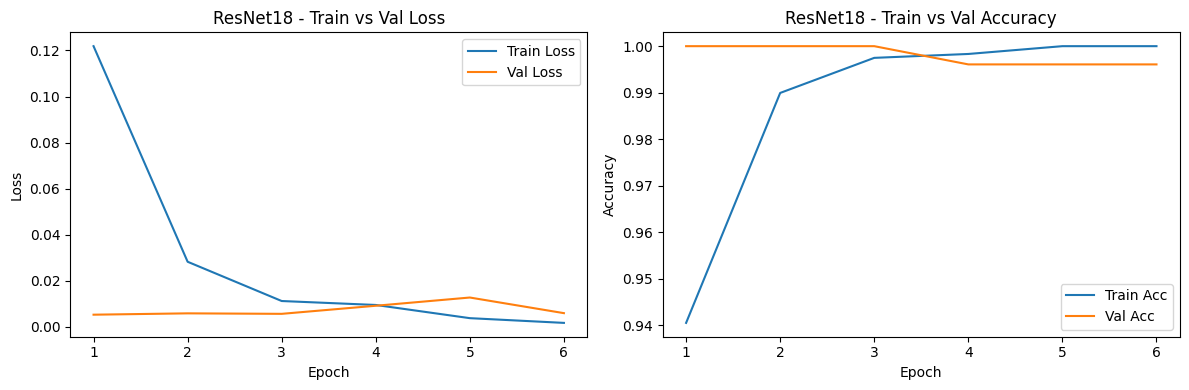

In [ ]:
history_resnet = train_model(
    resnet_model, train_loader, val_loader, criterion, optimizer,
    num_epochs=20, device=device, is_vit=False, save_prefix="resnet18",
    patience=5
)
plot_history(history_resnet, "ResNet18", f'{OUTPUT_DIR}/training_curves_resnet18.png')


### Test Evaluation


              precision    recall  f1-score   support

       horse       0.98      0.99      0.98       129
       zebra       0.99      0.98      0.98       128

    accuracy                           0.98       257
   macro avg       0.98      0.98      0.98       257
weighted avg       0.98      0.98      0.98       257

Confusion Matrix:
[[128   1]
 [  3 125]]


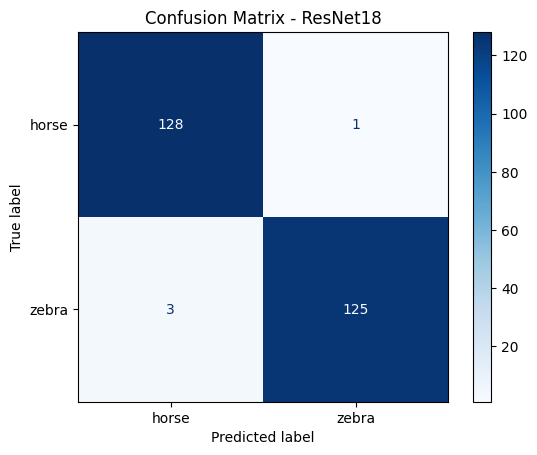

In [ ]:
_ = evaluate_model(
    resnet_model, test_loader, ['horse', 'zebra'], is_vit=False,
    title="ResNet18", save_path=f'{OUTPUT_DIR}/confusion_matrix_resnet18.png'
)


### Misclassified Examples


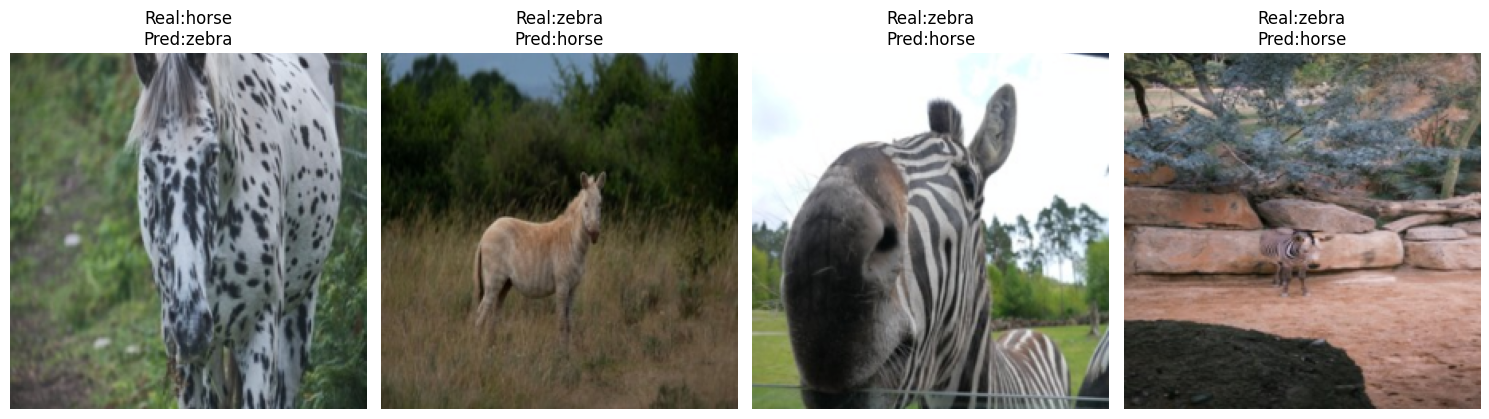

Total incorrect predictions: 4


In [ ]:
import matplotlib.pyplot as plt

resnet_model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu, labels_gpu = images.to(device), labels.to(device)
        outputs = resnet_model(images_gpu)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels_gpu[i]:
                wrong_images.append(images[i])
                wrong_true.append(labels[i].item())
                wrong_pred.append(predicted[i].item())

class_names = ['horse', 'zebra']
fig, axes = plt.subplots(1, max(len(wrong_images), 1), figsize=(15, 5))
if len(wrong_images) == 1:
    axes = [axes]
for i, img in enumerate(wrong_images):
    img = img.permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Real:{class_names[wrong_true[i]]}\nPred:{class_names[wrong_pred[i]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/wrong_predictions_resnet18.png', dpi=150)
plt.show()

print(f"Total incorrect predictions: {len(wrong_images)}")


## Bonus Model: EfficientNet-B0 (CNN, Transfer Learning)

An additional CNN transfer-learning comparison alongside ResNet18, using
the same fine-tuning strategy.


In [ ]:
import torchvision.models as models

efficientnet_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

num_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(num_features, 2)
efficientnet_model = efficientnet_model.to(device)

for param in efficientnet_model.parameters():
    param.requires_grad = True  # tum katmanlar egitilebilir (fine-tuning)

print(efficientnet_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficientnet_model.parameters(), lr=0.0001)  # dusuk lr, fine-tuning icin

Epoch 1/20 | Train Loss: 0.3061, Train Acc: 0.9170 | Val Loss: 0.0435, Val Acc: 0.9961
Epoch 2/20 | Train Loss: 0.0504, Train Acc: 0.9916 | Val Loss: 0.0187, Val Acc: 1.0000
Epoch 3/20 | Train Loss: 0.0178, Train Acc: 0.9983 | Val Loss: 0.0113, Val Acc: 1.0000
Epoch 4/20 | Train Loss: 0.0217, Train Acc: 0.9950 | Val Loss: 0.0086, Val Acc: 1.0000
Epoch 5/20 | Train Loss: 0.0091, Train Acc: 0.9983 | Val Loss: 0.0103, Val Acc: 1.0000
Epoch 6/20 | Train Loss: 0.0068, Train Acc: 0.9983 | Val Loss: 0.0050, Val Acc: 1.0000
Epoch 7/20 | Train Loss: 0.0054, Train Acc: 0.9992 | Val Loss: 0.0040, Val Acc: 1.0000
Epoch 8/20 | Train Loss: 0.0082, Train Acc: 0.9983 | Val Loss: 0.0072, Val Acc: 0.9961
Epoch 9/20 | Train Loss: 0.0062, Train Acc: 0.9992 | Val Loss: 0.0115, Val Acc: 0.9961
Epoch 10/20 | Train Loss: 0.0033, Train Acc: 1.0000 | Val Loss: 0.0029, Val Acc: 1.0000
Epoch 11/20 | Train Loss: 0.0061, Train Acc: 0.9983 | Val Loss: 0.0035, Val Acc: 1.0000
Epoch 12/20 | Train Loss: 0.0095, Train A

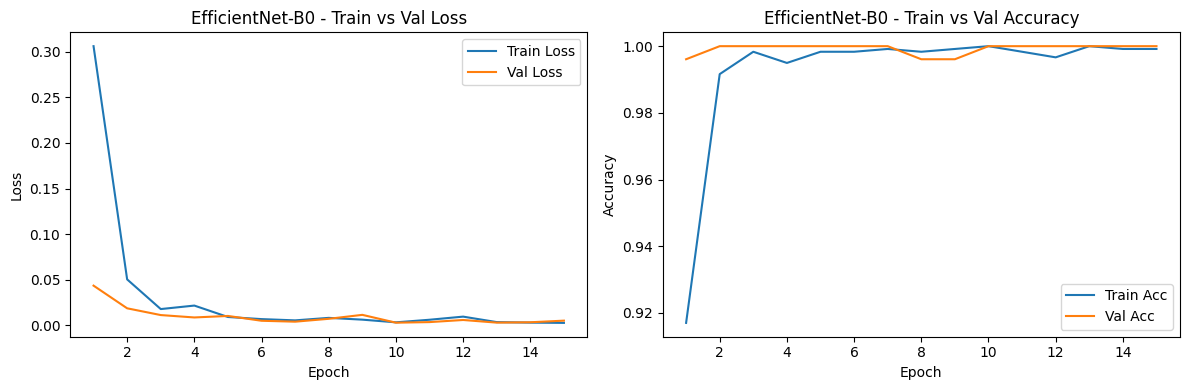

In [ ]:
history_efficientnet = train_model(
    efficientnet_model, train_loader, val_loader, criterion, optimizer,
    num_epochs=20, device=device, is_vit=False, save_prefix="efficientnet",
    patience=5
)

plot_history(history_efficientnet, "EfficientNet-B0", f'{OUTPUT_DIR}/training_curves_efficientnet.png')


              precision    recall  f1-score   support

       horse       0.98      1.00      0.99       129
       zebra       1.00      0.98      0.99       128

    accuracy                           0.99       257
   macro avg       0.99      0.99      0.99       257
weighted avg       0.99      0.99      0.99       257

Confusion Matrix:
[[129   0]
 [  2 126]]


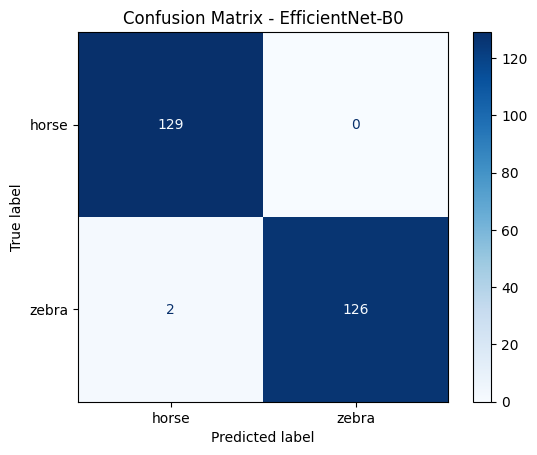

In [ ]:
_ = evaluate_model(
    efficientnet_model, test_loader, ['horse', 'zebra'], is_vit=False,
    title="EfficientNet-B0", save_path=f'{OUTPUT_DIR}/confusion_matrix_efficientnet.png'
)


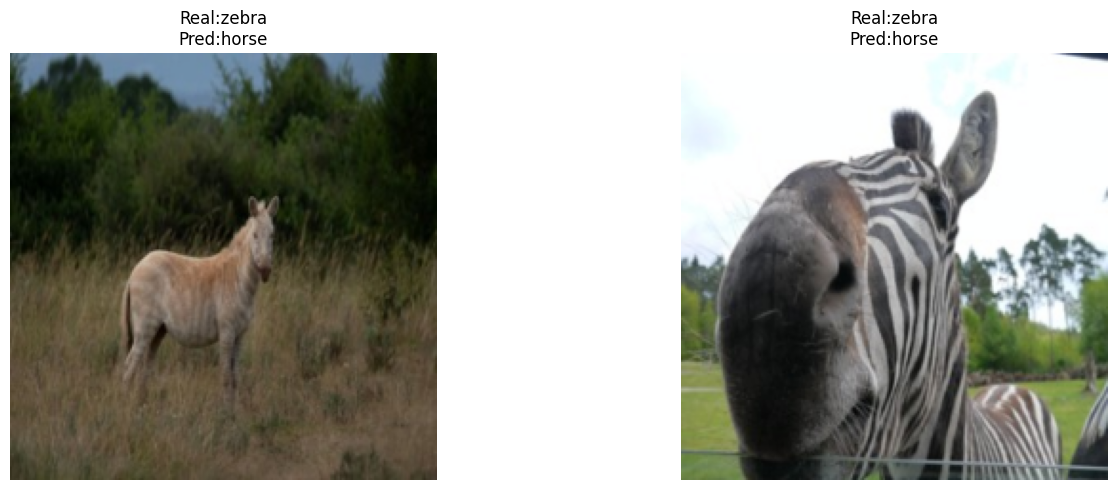

Total incorrect predictions: 2


In [ ]:
import matplotlib.pyplot as plt

efficientnet_model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu, labels_gpu = images.to(device), labels.to(device)
        outputs = efficientnet_model(images_gpu)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels_gpu[i]:
                wrong_images.append(images[i])
                wrong_true.append(labels[i].item())
                wrong_pred.append(predicted[i].item())

class_names = ['horse', 'zebra']
fig, axes = plt.subplots(1, max(len(wrong_images), 1), figsize=(15, 5))
if len(wrong_images) == 1:
    axes = [axes]
for i, img in enumerate(wrong_images):
    img = img.permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Real:{class_names[wrong_true[i]]}\nPred:{class_names[wrong_pred[i]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/wrong_predictions_efficientnet.png', dpi=150)
plt.show()

print(f"Total incorrect predictions: {len(wrong_images)}")


# Model 3: Vision Transformer (ViT)

Unlike a CNN, which processes images through small local filters, a
Vision Transformer splits the image into fixed-size patches and models
relationships between them via self-attention — conceptually similar to
how a language model relates words in a sentence, except the "tokens"
here are image patches.


In [ ]:
!pip install transformers --quiet

### Load Model & Processor


In [ ]:
import os
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"

from transformers import ViTForImageClassification, ViTImageProcessor

model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

vit_model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)
vit_model = vit_model.to(device)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


### ViT-Specific DataLoader

ViT does not use standard ImageNet normalization; it uses its own
`processor.image_mean` / `processor.image_std` values (`(0.5, 0.5, 0.5)`).
A separate transform and DataLoader are therefore required, distinct
from the ones used for SimpleCNN/ResNet18.


In [ ]:
vit_mean = processor.image_mean
vit_std = processor.image_std

vit_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=vit_mean, std=vit_std)
])

vit_val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=vit_mean, std=vit_std)
])

vit_train_dataset = datasets.ImageFolder(f'{DATASET_RESIZED_DIR}/train', transform=vit_train_transform)
vit_val_dataset = datasets.ImageFolder(f'{DATASET_RESIZED_DIR}/val', transform=vit_val_test_transform)
vit_test_dataset = datasets.ImageFolder(f'{DATASET_RESIZED_DIR}/test', transform=vit_val_test_transform)

vit_train_loader = DataLoader(vit_train_dataset, batch_size=16, shuffle=True)
vit_val_loader = DataLoader(vit_val_dataset, batch_size=16, shuffle=False)
vit_test_loader = DataLoader(vit_test_dataset, batch_size=16, shuffle=False)


### Loss & Optimizer

A very low learning rate (2e-5) is typical when fine-tuning ViT models.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=2e-5)

### Training (Shared Function, `is_vit=True`)


Epoch 1/15 | Train Loss: 0.1132, Train Acc: 0.9656 | Val Loss: 0.0192, Val Acc: 1.0000
Epoch 2/15 | Train Loss: 0.0083, Train Acc: 0.9975 | Val Loss: 0.0096, Val Acc: 1.0000
Epoch 3/15 | Train Loss: 0.0027, Train Acc: 1.0000 | Val Loss: 0.0062, Val Acc: 1.0000
Epoch 4/15 | Train Loss: 0.0015, Train Acc: 1.0000 | Val Loss: 0.0047, Val Acc: 1.0000
Epoch 5/15 | Train Loss: 0.0009, Train Acc: 1.0000 | Val Loss: 0.0036, Val Acc: 1.0000
Epoch 6/15 | Train Loss: 0.0006, Train Acc: 1.0000 | Val Loss: 0.0029, Val Acc: 1.0000
Epoch 7/15 | Train Loss: 0.0005, Train Acc: 1.0000 | Val Loss: 0.0024, Val Acc: 1.0000
Epoch 8/15 | Train Loss: 0.0004, Train Acc: 1.0000 | Val Loss: 0.0021, Val Acc: 1.0000
Epoch 9/15 | Train Loss: 0.0003, Train Acc: 1.0000 | Val Loss: 0.0018, Val Acc: 1.0000
Epoch 10/15 | Train Loss: 0.0002, Train Acc: 1.0000 | Val Loss: 0.0016, Val Acc: 1.0000
Epoch 11/15 | Train Loss: 0.0002, Train Acc: 1.0000 | Val Loss: 0.0014, Val Acc: 1.0000
Epoch 12/15 | Train Loss: 0.0002, Train A

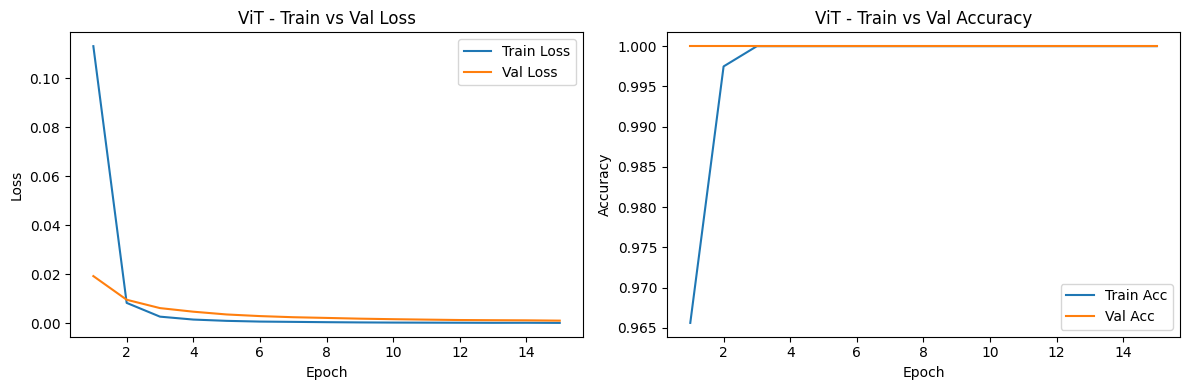

In [ ]:
history_vit = train_model(
    vit_model, vit_train_loader, vit_val_loader, criterion, optimizer,
    num_epochs=15, device=device, is_vit=True, save_prefix="vit",
    patience=3
)

plot_history(history_vit, "ViT", f'{OUTPUT_DIR}/training_curves_vit.png')


### Test Evaluation


              precision    recall  f1-score   support

       horse       0.99      1.00      1.00       129
       zebra       1.00      0.99      1.00       128

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257

Confusion Matrix:
[[129   0]
 [  1 127]]


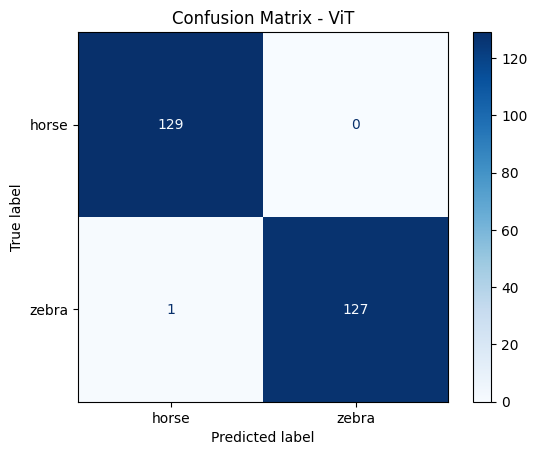

In [ ]:
_ = evaluate_model(
    vit_model, vit_test_loader, ['horse', 'zebra'], is_vit=True,
    title="ViT", save_path=f'{OUTPUT_DIR}/confusion_matrix_vit.png'
)


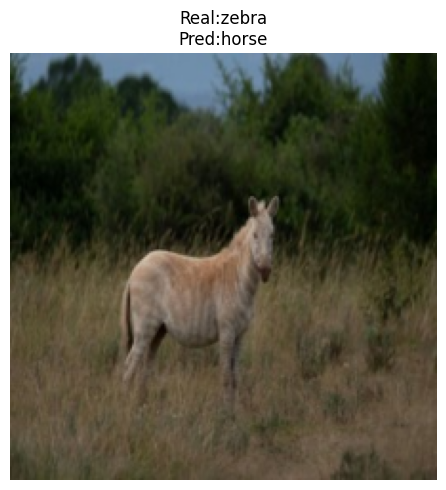

Total incorrect predictions: 1


In [ ]:
import matplotlib.pyplot as plt

vit_model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in vit_test_loader:
        images_gpu, labels_gpu = images.to(device), labels.to(device)
        outputs = vit_model(pixel_values=images_gpu).logits
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels_gpu[i]:
                wrong_images.append(images[i])
                wrong_true.append(labels[i].item())
                wrong_pred.append(predicted[i].item())

class_names = ['horse', 'zebra']
fig, axes = plt.subplots(1, max(len(wrong_images), 1), figsize=(15, 5))
if len(wrong_images) == 1:
    axes = [axes]

vit_mean = np.array(processor.image_mean)
vit_std = np.array(processor.image_std)

for i, img in enumerate(wrong_images):
    img = img.permute(1, 2, 0).numpy()
    img = img * vit_std + vit_mean   # ViT'in kendi normalize degerleriyle geri al
    img = img.clip(0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Real:{class_names[wrong_true[i]]}\nPred:{class_names[wrong_pred[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wrong_predictions_vit.png", dpi=150)
plt.show()

print(f"Total incorrect predictions: {len(wrong_images)}")

## Bonus Model 2: DeiT (Transformer, Transfer Learning)

A second Transformer architecture for comparison — Data-efficient Image
Transformer (DeiT), also pretrained on ImageNet.


In [ ]:
from transformers import ViTForImageClassification, ViTImageProcessor

deit_model_name = "facebook/deit-base-patch16-224"
deit_processor = ViTImageProcessor.from_pretrained(deit_model_name)

deit_model = ViTForImageClassification.from_pretrained(
    deit_model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)
deit_model = deit_model.to(device)

print(deit_model.classifier)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Linear(in_features=768, out_features=2, bias=True)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(deit_model.parameters(), lr=2e-5)  # dusuk lr, fine-tuning icin

Epoch 1/15 | Train Loss: 0.1093, Train Acc: 0.9740 | Val Loss: 0.0151, Val Acc: 0.9961
Epoch 2/15 | Train Loss: 0.0048, Train Acc: 0.9992 | Val Loss: 0.0146, Val Acc: 0.9961
Epoch 3/15 | Train Loss: 0.0034, Train Acc: 0.9992 | Val Loss: 0.0025, Val Acc: 1.0000
Epoch 4/15 | Train Loss: 0.0011, Train Acc: 1.0000 | Val Loss: 0.0046, Val Acc: 0.9961
Epoch 5/15 | Train Loss: 0.0004, Train Acc: 1.0000 | Val Loss: 0.0062, Val Acc: 0.9961
Epoch 6/15 | Train Loss: 0.0003, Train Acc: 1.0000 | Val Loss: 0.0079, Val Acc: 0.9961
Early stopping: val_loss did not improve for 3 epochs, stopping at epoch 6.


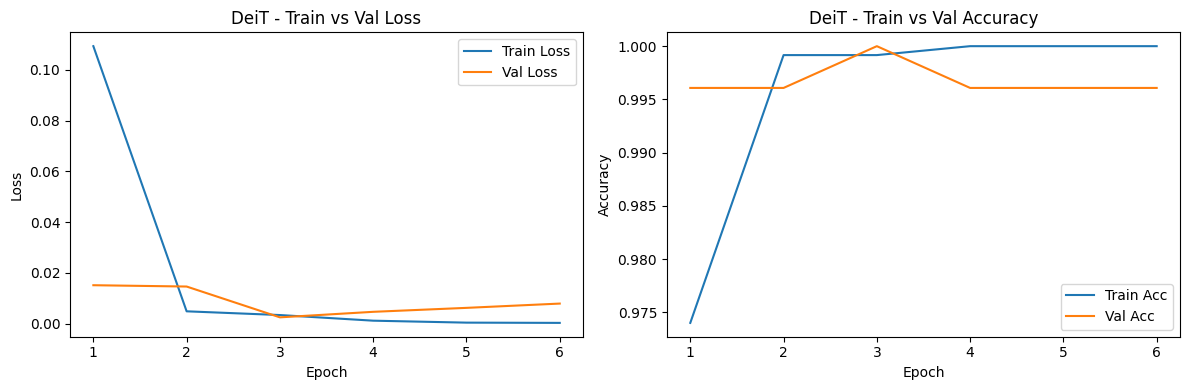

In [ ]:
history_deit = train_model(
    deit_model, vit_train_loader, vit_val_loader, criterion, optimizer,
    num_epochs=15, device=device, is_vit=True, save_prefix="deit",
    patience=3
)

plot_history(history_deit, "DeiT", f'{OUTPUT_DIR}/training_curves_deit.png')


              precision    recall  f1-score   support

       horse       0.99      1.00      1.00       129
       zebra       1.00      0.99      1.00       128

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257

Confusion Matrix:
[[129   0]
 [  1 127]]


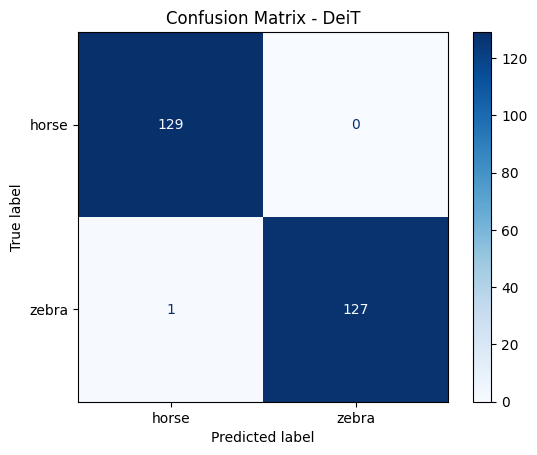

In [ ]:
_ = evaluate_model(
    deit_model, vit_test_loader, ['horse', 'zebra'], is_vit=True,
    title="DeiT", save_path=f'{OUTPUT_DIR}/confusion_matrix_deit.png'
)


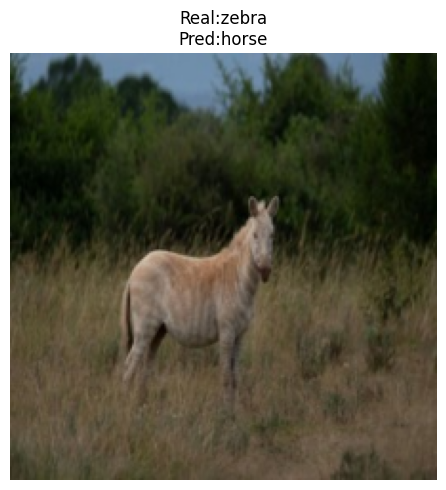

Total incorrect predictions: 1


In [ ]:
import matplotlib.pyplot as plt

deit_model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in vit_test_loader:
        images_gpu, labels_gpu = images.to(device), labels.to(device)
        outputs = deit_model(pixel_values=images_gpu).logits
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels_gpu[i]:
                wrong_images.append(images[i])
                wrong_true.append(labels[i].item())
                wrong_pred.append(predicted[i].item())

class_names = ['horse', 'zebra']
fig, axes = plt.subplots(1, max(len(wrong_images), 1), figsize=(15, 5))
if len(wrong_images) == 1:
    axes = [axes]

vit_mean = np.array(processor.image_mean)
vit_std = np.array(processor.image_std)

for i, img in enumerate(wrong_images):
    img = img.permute(1, 2, 0).numpy()
    img = img * vit_std + vit_mean
    img = img.clip(0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Real:{class_names[wrong_true[i]]}\nPred:{class_names[wrong_pred[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wrong_predictions_deit.png", dpi=150)
plt.show()

print(f"Total incorrect predictions: {len(wrong_images)}")

# Model Comparison (Training Curves)


### Load History Files

(Not needed if all models were trained in the same session — the
history dictionaries are already in memory.)


In [52]:
import json

with open(f'{OUTPUT_DIR}/history_scratch_cnn.json', 'r') as f:
    history_scratch = json.load(f)

with open(f'{OUTPUT_DIR}/history_resnet18.json', 'r') as f:
    history_resnet = json.load(f)

with open(f'{OUTPUT_DIR}/history_vit.json', 'r') as f:
    history_vit = json.load(f)


with open(f'{OUTPUT_DIR}/history_efficientnet.json', 'r') as f:
    history_resnet = json.load(f)

with open(f'{OUTPUT_DIR}/history_deit.json', 'r') as f:
    history_vit = json.load(f)

### Validation Loss / Accuracy Comparison — SimpleCNN vs. ResNet18 vs. ViT


In [60]:
def plot_model_comparison(histories, save_path, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

    for metric, ax, ylabel in [("val_loss", axes[0], "Val Loss"), ("val_acc", axes[1], "Val Accuracy")]:
        for name, hist, marker in histories:
            epochs = range(1, len(hist[metric]) + 1)
            ax.plot(epochs, hist[metric], label=name, marker=marker, linewidth=2)
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.set_title(f"Model Comparison{title_suffix} - {ylabel}")
        ax.legend(); ax.grid(alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

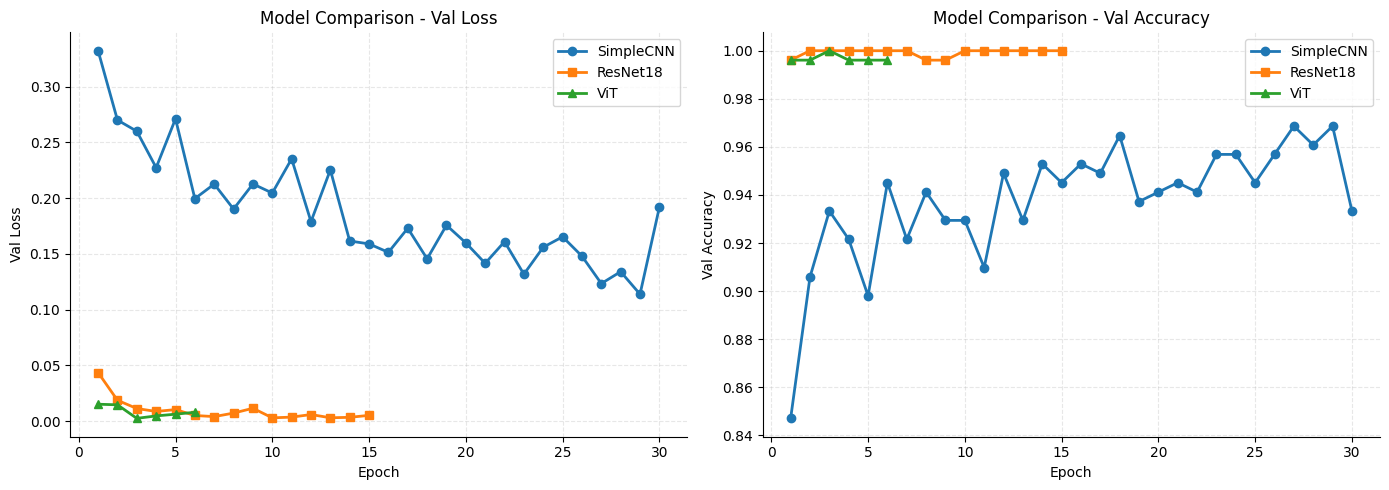

In [61]:
# 1. SimpleCNN vs ResNet18 vs ViT
plot_model_comparison(
    [("SimpleCNN", history_scratch, 'o'),
     ("ResNet18", history_resnet, 's'),
     ("ViT", history_vit, '^')],
    f'{OUTPUT_DIR}/model_comparison_both.png'
)



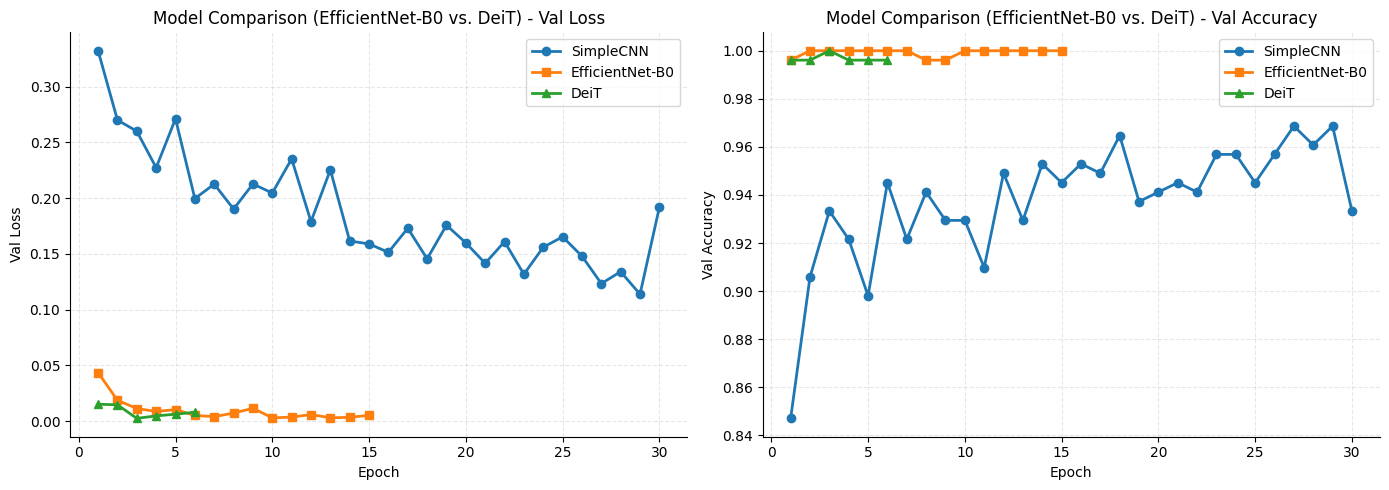

In [62]:
# 2. SimpleCNN vs EfficientNet-B0 vs DeiT
plot_model_comparison(
    [("SimpleCNN", history_scratch, 'o'),
     ("EfficientNet-B0", history_efficientnet, 's'),
     ("DeiT", history_deit, '^')],
    f'{OUTPUT_DIR}/model_comparison_both2.png',
    title_suffix=" (EfficientNet-B0 vs. DeiT)"
)

# Tricky Test Set — Evaluation on Hard Examples

A separate, AI-generated test set (Leonardo AI / Bing Image Creator /
Google Flow) — 100 images (50 horse / 50 zebra) featuring unusual
patterns, colors, and environments not present in the training
distribution. Used to probe how much each model relies on superficial
texture cues versus genuine shape/structure understanding.


In [63]:
!unzip -q {DRIVE_DIR}/ai_test.zip -d {BASE_DIR}/

# The archive's top-level folder name may not decode cleanly in all locales;
# normalize it to a clean AI_TEST_DIR path if needed.
import os
_raw_extracted = f"{BASE_DIR}/a\u0131"  # as produced by the original archive
if os.path.exists(_raw_extracted) and not os.path.exists(AI_TEST_DIR):
    os.rename(_raw_extracted, AI_TEST_DIR)


In [64]:
import os
print(os.listdir(BASE_DIR))


['.config', 'drive', 'dataset', 'data', 'dataset_resized', 'ai_test', 'sample_data']


In [65]:
print("Horse set:", len(os.listdir(f'{AI_TEST_DIR}/horse')))
print("Zebra set:", len(os.listdir(f'{AI_TEST_DIR}/zebra')))


Horse set: 50
Zebra set: 50


### Tricky DataLoader (SimpleCNN + ResNet18 + EfficientNet-B0 — ImageNet normalization)


In [66]:
ai_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ai_dataset = datasets.ImageFolder(AI_TEST_DIR, transform=ai_transform)
ai_loader = DataLoader(ai_dataset, batch_size=16, shuffle=False)

print("Classes:", ai_dataset.classes)
print("Total images:", len(ai_dataset))


Classes: ['horse', 'zebra']
Total images: 100


### Tricky DataLoader (ViT + DeiT — their own normalization values)


In [67]:
vit_ai_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])
vit_ai_dataset = datasets.ImageFolder(AI_TEST_DIR, transform=vit_ai_transform)
vit_ai_loader = DataLoader(vit_ai_dataset, batch_size=16, shuffle=False)

print("Total images (ViT):", len(vit_ai_dataset))


Total images (ViT): 100


### Evaluate All Models on Normal vs. AI Test Sets


In [68]:
scratch_normal_acc = test_accuracy(model, test_loader, is_vit=False)
scratch_ai_acc = test_accuracy(model, ai_loader, is_vit=False)
print(f"SimpleCNN  -> Normal: {scratch_normal_acc:.4f} | AI: {scratch_ai_acc:.4f}")

resnet_normal_acc = test_accuracy(resnet_model, test_loader, is_vit=False)
resnet_ai_acc = test_accuracy(resnet_model, ai_loader, is_vit=False)
print(f"ResNet18   -> Normal: {resnet_normal_acc:.4f} | AI: {resnet_ai_acc:.4f}")

vit_normal_acc = test_accuracy(vit_model, vit_test_loader, is_vit=True)
vit_ai_acc = test_accuracy(vit_model, vit_ai_loader, is_vit=True)
print(f"ViT        -> Normal: {vit_normal_acc:.4f} | AI: {vit_ai_acc:.4f}")


SimpleCNN  -> Normal: 0.9533 | AI: 0.6500
ResNet18   -> Normal: 0.9844 | AI: 0.7500
ViT        -> Normal: 0.9961 | AI: 0.8800


In [69]:
scratch_normal_acc = test_accuracy(model, test_loader, is_vit=False)
scratch_ai_acc = test_accuracy(model, ai_loader, is_vit=False)
print(f"SimpleCNN     -> Normal: {scratch_normal_acc:.4f} | AI: {scratch_ai_acc:.4f}")

efficientnet_normal_acc = test_accuracy(efficientnet_model, test_loader, is_vit=False)
efficientnet_ai_acc = test_accuracy(efficientnet_model, ai_loader, is_vit=False)
print(f"EfficientNet  -> Normal: {efficientnet_normal_acc:.4f} | AI: {efficientnet_ai_acc:.4f}")

deit_normal_acc = test_accuracy(deit_model, vit_test_loader, is_vit=True)
deit_ai_acc = test_accuracy(deit_model, vit_ai_loader, is_vit=True)
print(f"DeiT          -> Normal: {deit_normal_acc:.4f} | AI: {deit_ai_acc:.4f}")


SimpleCNN     -> Normal: 0.9533 | AI: 0.6500
EfficientNet  -> Normal: 0.9922 | AI: 0.8400
DeiT          -> Normal: 0.9961 | AI: 0.8300


# Final Visualizations

Summary plots comparing all trained models: normal vs. ai-set
accuracy, side by side.


### Normal vs. AI-Generated Test Performance (All Models)


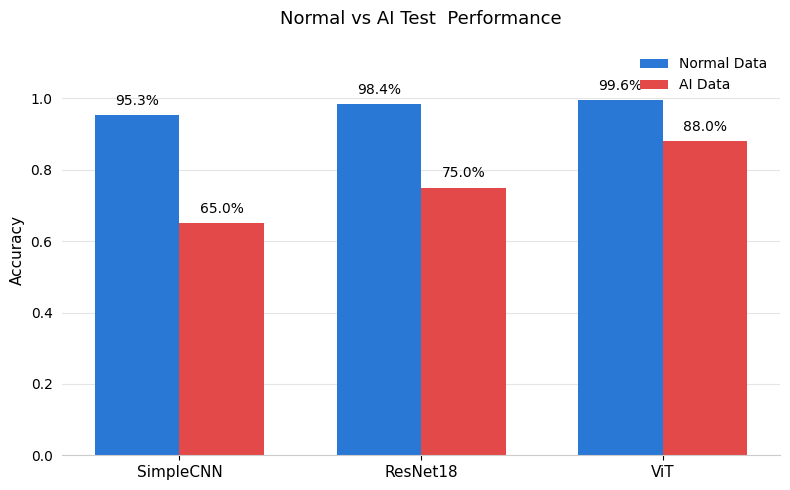

In [70]:
import numpy as np

def plot_normal_vs_tricky(save_path):
    models = ['SimpleCNN', 'ResNet18', 'ViT']
    normal_acc = [scratch_normal_acc, resnet_normal_acc, vit_normal_acc]
    ai_acc = [scratch_ai_acc, resnet_ai_acc, vit_ai_acc]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
    ax.set_facecolor('white')

    bars1 = ax.bar(x - width/2, normal_acc, width, label='Normal Data', color='#2a78d6')
    bars2 = ax.bar(x + width/2, ai_acc, width, label='AI Data', color='#e34948')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                    f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='medium')

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title('Normal vs AI Test  Performance', fontsize=13, fontweight='medium', pad=15)
    ax.legend(frameon=False, fontsize=10)
    ax.set_ylim(0, 1.15)

    ax.grid(alpha=0.2, linestyle='-', axis='y', color='gray')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(left=False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

plot_normal_vs_tricky(f'{OUTPUT_DIR}/normal_vs_tricky.png')


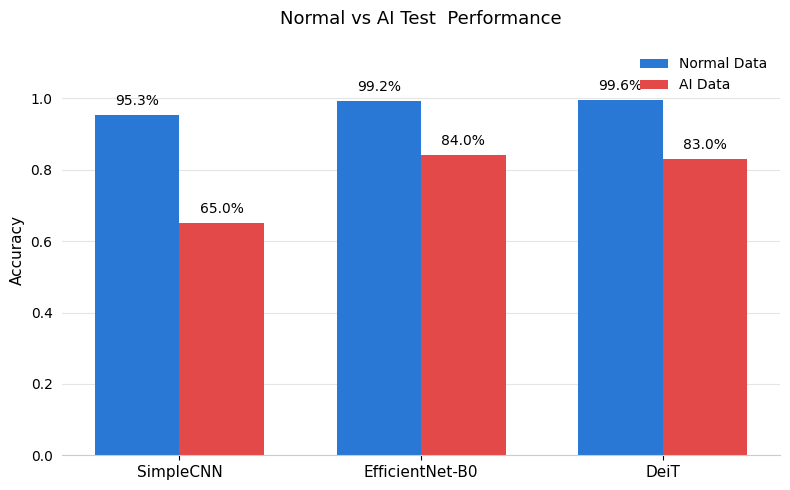

In [71]:
import numpy as np

def plot_normal_vs_tricky_v2(save_path):
    models = ['SimpleCNN', 'EfficientNet-B0', 'DeiT']
    normal_acc = [scratch_normal_acc, efficientnet_normal_acc, deit_normal_acc]
    ai_acc = [scratch_ai_acc, efficientnet_ai_acc, deit_ai_acc]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
    ax.set_facecolor('white')

    bars1 = ax.bar(x - width/2, normal_acc, width, label='Normal Data', color='#2a78d6')
    bars2 = ax.bar(x + width/2, ai_acc, width, label='AI Data', color='#e34948')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                    f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='medium')

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title('Normal vs AI Test  Performance', fontsize=13, fontweight='medium', pad=15)
    ax.legend(frameon=False, fontsize=10)
    ax.set_ylim(0, 1.15)

    ax.grid(alpha=0.2, linestyle='-', axis='y', color='gray')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(left=False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

plot_normal_vs_tricky_v2(f'{OUTPUT_DIR}/normal_vs_tricky_v2.png')


In [72]:
# Misclassified images on the tricky set (example: SimpleCNN)
model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in ai_loader:
        images_gpu, labels_gpu = images.to(device), labels.to(device)
        outputs = model(images_gpu)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            if predicted[i] != labels_gpu[i]:
                wrong_images.append(images[i])
                wrong_true.append(labels[i].item())
                wrong_pred.append(predicted[i].item())

print(f"Total incorrect predictions: {len(wrong_images)}")


Total incorrect predictions: 35
